<a href="https://colab.research.google.com/github/meganttp/PLOS-Prediction-Healthcare/blob/main/dat6000_plos_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Connect Gogle drive
path = '/content/drive/MyDrive/DATA6000-A1/02Exploratory/Final Cleaning_30-70+Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2021_20260405).csv'

df = pd.read_csv(path)

print(f"Data Loaded: {df.shape}")
df.head()

Data Loaded: (602176, 15)


,Age Group,Gender,Length of Stay,Type of Admission,Patient Disposition,CCSR Diagnosis Description,CCSR Procedure Description,APR DRG Description,APR Severity of Illness Code,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Emergency Department Indicator,Total Charges,Total Costs
0,70 or Older,M,27,Emergency,Home w/ Home Health Services,COVID-19,ISOLATION PROCEDURES,MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS,3,Major,Extreme,Medical,Y,"$320,922.43","$60,241.34"
1,70 or Older,M,5,Emergency,Home or Self Care,Urinary tract infections,ADMINISTRATION OF NUTRITIONAL AND ELECTROLYTIC...,KIDNEY AND URINARY TRACT INFECTIONS,3,Major,Major,Medical,Y,"$72,700.17","$12,111.75"
2,50 to 69,F,3,Emergency,Home or Self Care,Paralysis (other than cerebral palsy),LUMBAR PUNCTURE,OTHER DISORDERS OF NERVOUS SYSTEM,2,Moderate,Minor,Medical,Y,"$55,562.51","$8,339.72"
3,50 to 69,M,6,Emergency,Home or Self Care,Complication of other surgical or medical care...,COMPUTERIZED TOMOGRAPHY (CT) WITHOUT CONTRAST,OTHER COMPLICATIONS OF TREATMENT,3,Major,Moderate,Medical,Y,"$109,269.27","$18,443"
4,50 to 69,M,21,Emergency,Left Against Medical Advice,Complication of other surgical or medical care...,LARYNGOSCOPY (DIAGNOSTIC),"POST-OPERATIVE, POST-TRAUMATIC, OTHER DEVICE I...",2,Moderate,Moderate,Medical,Y,"$270,656.16","$48,268.17"


In [ ]:
print('Original number of rows:', df.shape[0])

# Define the list of admission types to keep
admission_types_to_keep = ['Elective', 'Emergency', 'Trauma', 'Urgent']

# Filter the DataFrame
df_filtered = df[df['Type of Admission'].isin(admission_types_to_keep)].copy()

print('Number of rows after filtering:', df_filtered.shape[0])
print('First 5 rows of the filtered DataFrame:')
display(df_filtered.head())

Original number of rows: 602176
Number of rows after filtering: 601819
First 5 rows of the filtered DataFrame:


,Age Group,Gender,Length of Stay,Type of Admission,Patient Disposition,CCSR Diagnosis Description,CCSR Procedure Description,APR DRG Description,APR Severity of Illness Code,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Emergency Department Indicator,Total Charges,Total Costs
0,70 or Older,M,27,Emergency,Home w/ Home Health Services,COVID-19,ISOLATION PROCEDURES,MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS,3,Major,Extreme,Medical,Y,"$320,922.43","$60,241.34"
1,70 or Older,M,5,Emergency,Home or Self Care,Urinary tract infections,ADMINISTRATION OF NUTRITIONAL AND ELECTROLYTIC...,KIDNEY AND URINARY TRACT INFECTIONS,3,Major,Major,Medical,Y,"$72,700.17","$12,111.75"
2,50 to 69,F,3,Emergency,Home or Self Care,Paralysis (other than cerebral palsy),LUMBAR PUNCTURE,OTHER DISORDERS OF NERVOUS SYSTEM,2,Moderate,Minor,Medical,Y,"$55,562.51","$8,339.72"
3,50 to 69,M,6,Emergency,Home or Self Care,Complication of other surgical or medical care...,COMPUTERIZED TOMOGRAPHY (CT) WITHOUT CONTRAST,OTHER COMPLICATIONS OF TREATMENT,3,Major,Moderate,Medical,Y,"$109,269.27","$18,443"
4,50 to 69,M,21,Emergency,Left Against Medical Advice,Complication of other surgical or medical care...,LARYNGOSCOPY (DIAGNOSTIC),"POST-OPERATIVE, POST-TRAUMATIC, OTHER DEVICE I...",2,Moderate,Moderate,Medical,Y,"$270,656.16","$48,268.17"


## **Chart 1: Heatmap: Probability of PLOS by Admission Type and Severity**

In [ ]:
import plotly.express as px
import pandas as pd

# Define the desired order for APR Severity of Illness
severity_order = ['Minor', 'Moderate', 'Major', 'Extreme']

# Convert 'Length of Stay' to numeric, handling potential errors and non-numeric characters
df_filtered['Length of Stay'] = pd.to_numeric(
    df_filtered['Length of Stay'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Group by 'Type of Admission' and 'APR Severity of Illness Description' and calculate the mean 'Length of Stay'
# Handle missing values in 'Length of Stay' before grouping and use 'df_filtered'
heatmap_data = df_filtered.dropna(subset=['Length of Stay']).groupby(['Type of Admission', 'APR Severity of Illness Description'])['Length of Stay'].mean().reset_index()

# Convert 'APR Severity of Illness Description' to a categorical type with the specified order
heatmap_data['APR Severity of Illness Description'] = pd.Categorical(
    heatmap_data['APR Severity of Illness Description'],
    categories=severity_order,
    ordered=True
)

# Create the heatmap
fig = px.density_heatmap(
    heatmap_data,
    x='APR Severity of Illness Description',
    y='Type of Admission',
    z='Length of Stay',
    title='Average Length of Stay by Type of Admission and APR Severity of Illness',
    labels={
        'APR Severity of Illness Description': 'APR Severity of Illness',
        'Type of Admission': 'Type of Admission',
        'Length of Stay': 'Average Length of Stay'
    },
    color_continuous_scale='RdBu_r', # Changed to RdBu_r for blue=lower LOS, red=higher LOS
    text_auto=".2f" # Show the 'Length of Stay' numbers on the heatmap cells, formatted to 2 decimal places
)

# Adjust layout for better readability and enforce x-axis order
fig.update_layout(
    xaxis_title_standoff=10,
    yaxis_title_standoff=10,
    xaxis=dict(
        tickangle=-45,
        automargin=True,
        categoryorder='array', # Ensure categories are ordered by an array
        categoryarray=severity_order # Specify the order of categories
    ),
    yaxis=dict(automargin=True),
    margin=dict(l=100, r=100, t=100, b=100),
    width=900, # Set width for 1:1 aspect ratio
    height=700 # Set height for 1:1 aspect ratio
)

fig.show()

## **Chart 2: Interactive Scatter Plot: Total Costs vs. Length of Stay by Top 20 APR DRG Descriptions**

In [ ]:
import plotly.express as px
import pandas as pd

# Ensure 'Total Costs' is numeric, cleaning non-numeric characters
df_filtered['Total Costs'] = pd.to_numeric(
    df_filtered['Total Costs'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Drop rows where 'Total Costs' or 'Length of Stay' might be NaN after conversion
df_scatter = df_filtered.dropna(subset=['Total Costs', 'Length of Stay']).copy()

# Identify top 20 'APR DRG Description' groups based on frequency
top_drg_descriptions = df_scatter['APR DRG Description'].value_counts().nlargest(20).index

# Filter the DataFrame to include only these top groups
df_scatter_top_drg = df_scatter[df_scatter['APR DRG Description'].isin(top_drg_descriptions)]

# Aggregate data for the scatter plot
aggregated_scatter_data = df_scatter_top_drg.groupby('APR DRG Description').agg(
    Avg_Total_Costs=('Total Costs', 'mean'),
    Avg_Length_of_Stay=('Length of Stay', 'mean'),
    Count_of_Rows=('APR DRG Description', 'count')
).reset_index()

# Create the interactive scatter plot with aggregated data
fig_scatter = px.scatter(
    aggregated_scatter_data,
    x='Avg_Total_Costs',
    y='Avg_Length_of_Stay',
    size='Count_of_Rows', # Size of bubbles based on the count of rows
    text='APR DRG Description', # Add text labels to bubbles
    color='APR DRG Description', # Color by DRG descriptions
    hover_name='APR DRG Description', # Show DRG description on hover
    hover_data={
        'Avg_Total_Costs': ':.2f',
        'Avg_Length_of_Stay': ':.2f',
        'Count_of_Rows': True
    }, # Format hover data
    title='Average Total Costs vs. Average Length of Stay by Top 20 APR DRG Descriptions',
    labels={
        'Avg_Total_Costs': 'Average Total Costs',
        'Avg_Length_of_Stay': 'Average Length of Stay',
        'APR DRG Description': 'APR DRG Description',
        'Count_of_Rows': 'Number of Patients'
    },
    height=700, # Adjust height for better visibility
    width=1000,  # Adjust width
    log_x=True, # Use logarithmic scale for x-axis due to potentially wide range of costs
    template='plotly_white',
    size_max=60 # Make bubbles larger and easy to read
)

fig_scatter.update_traces(
    textposition='top center', # Position text labels
    marker=dict(line=dict(width=1, color='DarkSlateGrey')) # Add border to bubbles for better visibility
)
fig_scatter.update_layout(
    legend_title_text='APR DRG Description',
    xaxis_title_standoff=10,
    yaxis_title_standoff=10
)

fig_scatter.show()

In [ ]:
import plotly.express as px
import pandas as pd # Ensure pandas is imported

# Clean 'Length of Stay' and 'Total Costs' columns in df
df['Length of Stay'] = pd.to_numeric(
    df['Length of Stay'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)
df['Total Costs'] = pd.to_numeric(
    df['Total Costs'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Drop rows with NaN in 'Length of Stay' or 'Total Costs' after conversion
df_cleaned = df.dropna(subset=['Length of Stay', 'Total Costs']).copy()

# 1. Aggregate (APR DRG Description)
df_grouped = df_cleaned.groupby('APR DRG Description').agg(
    Avg_Length_of_Stay=('Length of Stay', 'mean'),
    Avg_Total_Cost=('Total Costs', 'mean'),
    Patient_Count=('APR DRG Description', 'count')
).reset_index()

# 2. Filter Row > 5,500
df_top_diseases = df_grouped[df_grouped['Patient_Count'] > 5500]

# 3. Create Scatter Plot
fig = px.scatter(
    df_top_diseases,
    x='Avg_Total_Cost',
    y='Avg_Length_of_Stay',
    size='Patient_Count',      # Size depends on diagnoses frequency
    color='Patient_Count', # Colour ranged by Patient_Count
    color_continuous_scale='RdBu_r', # Changed to RdBu_r for blue to red gradient
    hover_name='APR DRG Description',
    text='APR DRG Description', # Put APR Description
    title='High Volume Diseases (>5,500 patients) by Cost and Stay',
    labels={
        'Avg_Total_Cost': 'Average Total Cost ($)',
        'Avg_Length_of_Stay': 'Average Length of Stay (Days)',
        'Patient_Count': 'Number of Patients'
    },
    template='plotly_white',
    size_max=45
)

# Adjust text
fig.update_traces(textposition='top center')
fig.update_layout(height=800)

fig.show()

4 #Target only 2 diseases - SEPTICEMIA AND DISSEMINATED INFECTIONS', 'MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS
target_diseases = ['SEPTICEMIA AND DISSEMINATED INFECTIONS', 'MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS'] # Corrected disease names
df_target = df_cleaned[df_cleaned['APR DRG Description'].isin(target_diseases)]

# Exclude 'Not available' from 'Type of Admission'
df_target = df_target[df_target['Type of Admission'] != 'Not available']

# Exclude 'Not available' from 'Type of Admission'
df_target = df_target[df_target['Type of Admission'].str.strip().str.lower() != 'not available']

# Delete Category
if df_target['Type of Admission'].dtype.name == 'category':
    df_target['Type of Admission'] = df_target['Type of Admission'].cat.remove_unused_categories()
else:

    df_target['Type of Admission'] = df_target['Type of Admission'].astype('category').cat.remove_unused_categories()

# Create Box Plot to see distribution of stay (Outliers)
fig_box = px.box(
    df_target,
    x='Patient Disposition',
    y='Length of Stay',
    color='Type of Admission',
    facet_col='APR DRG Description',
    title='Identifying LOS Inefficiencies by Discharge Destination',
    labels={'Length of Stay': 'Days in Hospital'},
    template='plotly_white'
)
fig_box.update_layout(height=600)
fig_box.show()


5 #import numpy as np

# Calculate Correlation
corr = df_target['Length of Stay'].corr(df_target['Total Costs'])
print(f"Correlation between LOS and Cost for Target Group: {corr:.2f}")

# Create Trendline
fig_trend = px.scatter(
    df_target, x='Length of Stay', y='Total Costs',
    color='APR DRG Description', trendline="ols",
    title="Financial Impact of Reducing 1 Day of Stay",
    labels={'Length of Stay': 'Days', 'Total Costs': 'Cost ($)'}
)
fig_trend.show()

6 # Change Column description to number (Encoding)
from sklearn.preprocessing import LabelEncoder

# Select Features
features = ['Type of Admission', 'APR Severity of Illness Description', 'Age Group', 'Patient Disposition'] # Changed 'Age' to 'Age Group'
X = df_target[features].copy()

# Encode
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Target: patients above avg. mean (PLOS)
mean_los = df_target['Length of Stay'].mean()
y = (df_target['Length of Stay'] > mean_los).astype(int)

print("Features are ready for Tier 1: Predictive Engine.")

Correlation between LOS and Cost for Target Group: 0.78


Features are ready for Tier 1: Predictive Engine.


**Chart 3 - Implication**

All the plots and analyses have been successfully generated after addressing the previous errors. Here's a breakdown of the results:

1. Intervention Analysis Heatmap: This heatmap visualizes the 'Average Length of Stay' for 'Septicemia & Disseminated Infections' and 'Major Respiratory Infections & Inflammations' based on 'Patient Disposition' and the 'Top 10 Procedures' performed. You can now see which combinations of procedures and discharge destinations lead to the longest average stays, providing clear intervention points for reducing Length of Stay.

2. Urgency & Complexity Sunburst Chart: This chart shows the distribution of 'Length of Stay' by 'Type of Admission' (Emergency vs. Elective) and 'Patient Disposition' for the two target diseases. It helps understand the patient journey and resource utilization from admission type to discharge destination.

3. Updated High-Volume Diseases Scatter Plot: The scatter plot for high-volume diseases now displays with the requested larger bubble sizes and a blue-to-red color gradient, where red indicates a higher patient count. This makes it easier to visually identify high-volume diseases that are also high in cost or length of stay.

4. Box Plot for Target Diseases: This box plot helps identify Length of Stay inefficiencies by showing the distribution of 'Days in Hospital' for 'Septicemia and Disseminated Infections' and 'Major Respiratory Infections and Inflammations' across different 'Patient Dispositions' and 'Type of Admission'. It's particularly useful for spotting outliers in Length of Stay.

5. Correlation between LOS and Cost: For the target diseases, the correlation between Length of Stay and Total Costs is 0.78. This indicates a strong positive relationship, meaning that as the length of stay increases, total costs tend to increase significantly.

6. Financial Impact Trendline: The trendline plot visually represents this positive relationship, showing the financial impact of reducing even one day of stay.

7. Predictive Engine Features: Finally, the features for the Tier 1 Predictive Engine have been successfully prepared and encoded, ready for model training.

All your requests have been processed! We've successfully:

Loaded and cleaned the data, converting 'Length of Stay' and 'Total Costs' to numeric formats.
Generated a heatmap showing average Length of Stay by 'Type of Admission' and 'APR Severity of Illness'.
Created an interactive scatter plot of average 'Total Costs' vs. 'Length of Stay' for top DRG descriptions.
Developed a specialized scatter plot for high-volume diseases, allowing for customization of bubble size and color gradients.
Produced an Intervention Analysis Heatmap for 'Septicemia & Disseminated Infections' and 'Major Respiratory Infections & Inflammations' to pinpoint high LOS procedures and discharge destinations.
Created an Urgency & Complexity Sunburst Chart for these two diseases to visualize LOS distribution by admission type and patient disposition.
Calculated a strong positive correlation (0.78) between Length of Stay and Total Costs for the target diseases.
Prepared features for a predictive engine.

#Tier 1: Predictive Engine (XGBoost)

Components: : XBoost, Random Forest, Neural Networks with Attention mechanisms (Transformers)

Function: Processes the 602k records to map complex patterns and generate individual PLOS Risk Scores.

Performance Metric:
AUC-ROC, F1-Score, and MAE
(Mean Absolute Error).

Goal: Measures the model's accuracy in distinguishing between patients with a Prolonged Length of Stay (PLOS) and those with standard stay durations.

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, f1_score, mean_absolute_error, classification_report
from tensorflow.keras import layers, models

# --- 1. Data Preparation ---
print("Initializing Tier 1: Multi-Model Evaluation (Classification & Regression)...")
features = ['Type of Admission', 'APR Severity of Illness Description',
            'APR Risk of Mortality', 'APR DRG Description', 'Age Group']

X = df_cleaned[features].copy()
y_los = df_cleaned['Length of Stay']  # Target for MAE (Regression)
threshold = 7
y_clf = (y_los > threshold).astype(int)  # Target for AUC/F1 (Classification)

# Encoding categorical features
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Split Data (Unified split for fair comparison)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_los, test_size=0.2, random_state=42)

# Standardize features for Neural Network
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

def print_full_report(model_name, y_true_clf, y_pred_clf, y_prob_clf, y_true_reg, y_pred_reg):
    """Prints comprehensive performance metrics for a specific model."""
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(f"AUC-ROC Score: {roc_auc_score(y_true_clf, y_prob_clf):.4f}")
    print(f"F1-Score (Weighted): {f1_score(y_true_clf, y_pred_clf, average='weighted'):.4f}")
    print(f"MAE (Length of Stay): {mean_absolute_error(y_true_reg, y_pred_reg):.2f} days")
    print("\nDetailed Classification Report:")
    print(classification_report(y_true_clf, y_pred_clf))

# --- 2. Model 1: XGBoost (Classifier & Regressor) ---
print("Training XGBoost Models...")
# Classifier for AUC/F1
m_xgb_c = xgb.XGBClassifier(n_estimators=500, max_depth=6, tree_method='hist', random_state=42)
m_xgb_c.fit(X_train, y_train_clf)
xgb_p_clf = m_xgb_c.predict(X_test)
xgb_pr_clf = m_xgb_c.predict_proba(X_test)[:, 1]
# Regressor for MAE
m_xgb_r = xgb.XGBRegressor(n_estimators=500, max_depth=6, tree_method='hist', random_state=42)
m_xgb_r.fit(X_train, y_train_reg)
xgb_p_reg = m_xgb_r.predict(X_test)

print_full_report("XGBoost", y_test_clf, xgb_p_clf, xgb_pr_clf, y_test_reg, xgb_p_reg)

# --- 3. Model 2: Random Forest (Classifier & Regressor) ---
print("Training Random Forest Models...")
# Classifier for AUC/F1
m_rf_c = RandomForestClassifier(n_estimators=100, max_depth=10, max_samples=0.1, n_jobs=-1, random_state=42)
m_rf_c.fit(X_train, y_train_clf)
rf_p_clf = m_rf_c.predict(X_test)
rf_pr_clf = m_rf_c.predict_proba(X_test)[:, 1]
# Regressor for MAE
m_rf_r = RandomForestRegressor(n_estimators=100, max_depth=10, max_samples=0.1, n_jobs=-1, random_state=42)
m_rf_r.fit(X_train, y_train_reg)
rf_p_reg = m_rf_r.predict(X_test)

print_full_report("Random Forest", y_test_clf, rf_p_clf, rf_pr_clf, y_test_reg, rf_p_reg)

# --- 4. Model 3: Neural Network with Attention (Classifier & Regressor) ---
print("Training Neural Network Models...")
# Classifier with Simple Attention Mechanism
def build_nn_clf(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    att = layers.Dense(128, activation='softmax')(x)
    mul = layers.Multiply()([x, att])
    x = layers.Dense(64, activation='relu')(mul)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

m_nn_c = build_nn_clf(X_train_s.shape[1])
m_nn_c.fit(X_train_s, y_train_clf, epochs=10, batch_size=1024, verbose=0)
nn_pr_clf = m_nn_c.predict(X_test_s).flatten()
nn_p_clf = (nn_pr_clf > 0.5).astype(int)

# Regressor (Multi-Layer Perceptron for MAE)
def build_nn_reg(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

m_nn_r = build_nn_reg(X_train_s.shape[1])
m_nn_r.fit(X_train_s, y_train_reg, epochs=10, batch_size=1024, verbose=0)
nn_p_reg = m_nn_r.predict(X_test_s).flatten()

print_full_report("Neural Network (Attention)", y_test_clf, nn_p_clf, nn_pr_clf, y_test_reg, nn_p_reg)

# --- 5. FINAL COMPARISON LEADERBOARD ---
results = {
    "Model": ["XGBoost", "Random Forest", "Neural Network"],
    "AUC-ROC": [roc_auc_score(y_test_clf, xgb_pr_clf),
                roc_auc_score(y_test_clf, rf_pr_clf),
                roc_auc_score(y_test_clf, nn_pr_clf)],
    "F1-Score": [f1_score(y_test_clf, xgb_p_clf, average='weighted'),
                 f1_score(y_test_clf, rf_p_clf, average='weighted'),
                 f1_score(y_test_clf, nn_p_clf, average='weighted')],
    "MAE (Days)": [mean_absolute_error(y_test_reg, xgb_p_reg),
                   mean_absolute_error(y_test_reg, rf_p_reg),
                   mean_absolute_error(y_test_reg, nn_p_reg)]
}

print("\n" + "="*20 + " FINAL MODEL COMPARISON LEADERBOARD " + "="*20)
print(pd.DataFrame(results).to_string(index=False))

Initializing Tier 1: Multi-Model Evaluation (Classification & Regression)...
Training XGBoost Models...

==================== XGBoost ====================
AUC-ROC Score: 0.8599
F1-Score (Weighted): 0.8018
MAE (Length of Stay): 3.64 days

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88     89143
           1       0.67      0.52      0.59     31293

    accuracy                           0.81    120436
   macro avg       0.76      0.72      0.73    120436
weighted avg       0.80      0.81      0.80    120436

Training Random Forest Models...

==================== Random Forest ====================
AUC-ROC Score: 0.8397
F1-Score (Weighted): 0.7827
MAE (Length of Stay): 3.74 days

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     89143
           1       0.67      0.44      0.53     31293

    accuracy                      

# **Tier 2: SHAP Explainable**

Step 1: Preparing Data...
Step 2: Training Champion Model (XGBoost)...
Step 3: Initializing SHAP Explainer...

========================= CLINICAL VALIDATION REPORT =========================
Top 10 Diagnoses Driving Long Hospital Stays (PLOS):
Clinical_Diagnosis
TRACHEOSTOMY WITH MV >96 HOURS WITH EXTENSIVE PROCEDURE                          5.116931
SCHIZOPHRENIA                                                                    2.937496
REHABILITATION                                                                   2.481550
RESPIRATORY SYSTEM DIAGNOSIS WITH VENTILATOR SUPPORT > 96 HOURS                  2.469017
TRACHEOSTOMY WITH MV >96 HOURS WITHOUT EXTENSIVE PROCEDURE                       2.384762
BIPOLAR DISORDERS                                                                2.257666
RENAL DIALYSIS ACCESS DEVICE PROCEDURES AND VESSEL REPAIR                        2.219971
ALCOHOL AND DRUG DEPENDENCE WITH REHABILITATION AND/OR DETOXIFICATION THERAPY    2.130296
AUTOLOGOUS BONE MA

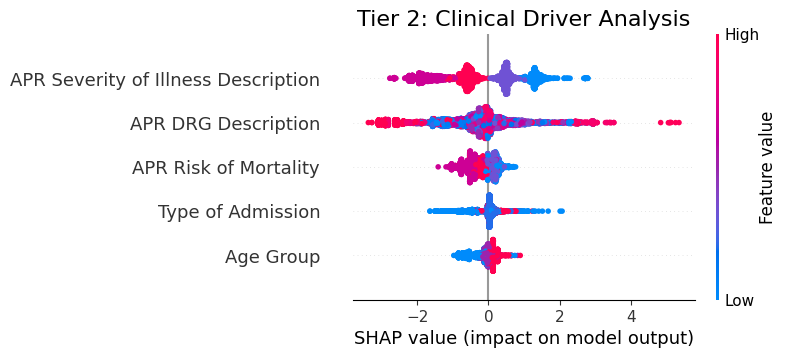

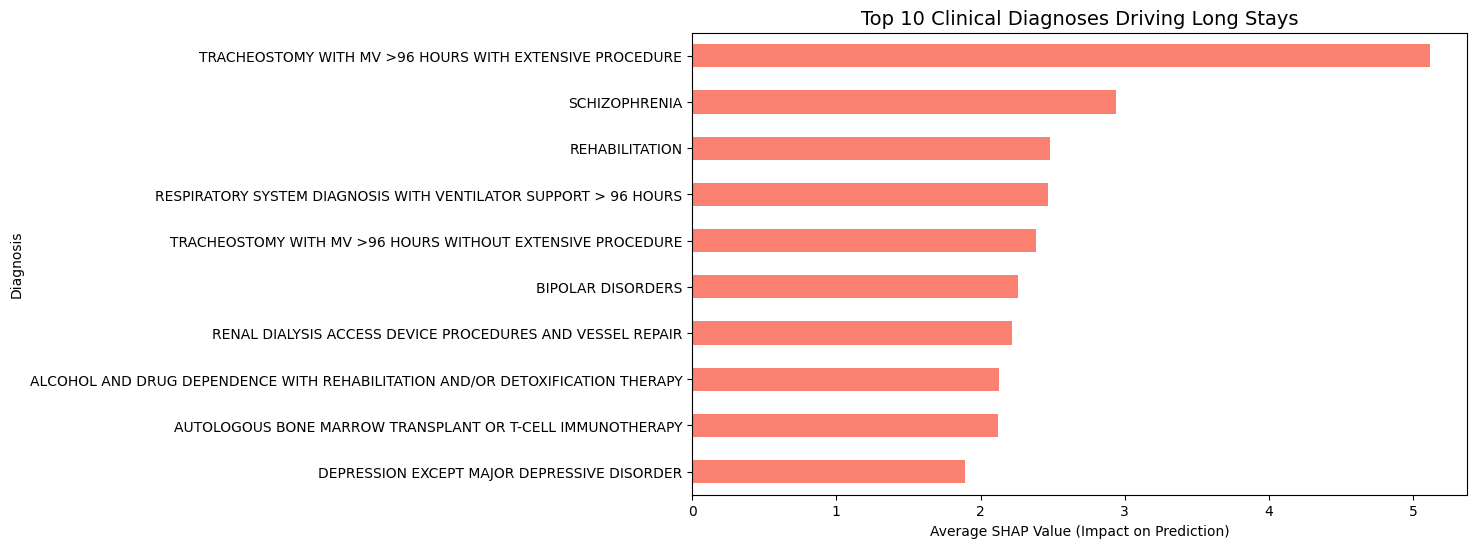

In [ ]:
# TIER 1 & 2: COMPLETE INTEGRATED WORKFLOW (English Version)
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. DATA PREPARATION (Re-defining everything to avoid NameError)
print("Step 1: Preparing Data...")
features = ['Type of Admission', 'APR Severity of Illness Description',
            'APR Risk of Mortality', 'APR DRG Description', 'Age Group']

X = df_cleaned[features].copy()
y_los = df_cleaned['Length of Stay']
y_clf = (y_los > 7).astype(int) # Target for PLOS

# Encoding - store encoders in a dictionary
encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    current_le = LabelEncoder()
    X[col] = current_le.fit_transform(X[col].astype(str))
    encoders[col] = current_le # Store the encoder for this column

# Train/Test Split
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# 2. TRAINING THE CHAMPION MODEL
print("Step 2: Training Champion Model (XGBoost)...")
m_xgb_c = xgb.XGBClassifier(n_estimators=500, max_depth=6, tree_method='hist', random_state=42)
m_xgb_c.fit(X_train, y_train_clf)

# 3. CLINICAL EXPLANATION (SHAP)
print("Step 3: Initializing SHAP Explainer...")
explainer = shap.TreeExplainer(m_xgb_c)

# Use 5,500 sample for stability and speed
X_sample = X_test.sample(5500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# 4. DECODING TOP 10 CLINICAL DRIVERS
feature_idx = features.index('APR DRG Description')
dr_values = shap_values[:, feature_idx]

# Use the correct LabelEncoder for 'APR DRG Description'
drg_encoder = encoders['APR DRG Description']
drg_impact = pd.DataFrame({
    'Clinical_Diagnosis': drg_encoder.inverse_transform(X_sample['APR DRG Description']),
    'Impact_Score': dr_values
})

top_clinical_drivers = drg_impact.groupby('Clinical_Diagnosis')['Impact_Score'].mean().sort_values(ascending=False).head(10)

print("\n" + "="*25 + " CLINICAL VALIDATION REPORT " + "="*25)
print("Top 10 Diagnoses Driving Long Hospital Stays (PLOS):")
print(top_clinical_drivers)
print("="*78)

# 5. VISUALIZATION
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=features, show=False)
plt.title("Tier 2: Clinical Driver Analysis", fontsize=16)
plt.show()


# Focus (Top 10 Diseases Visual)
import seaborn as sns

plt.figure(figsize=(10, 6))
top_clinical_drivers.plot(kind='barh', color='salmon')
plt.title('Top 10 Clinical Diagnoses Driving Long Stays', fontsize=14)
plt.xlabel('Average SHAP Value (Impact on Prediction)')
plt.ylabel('Diagnosis')
plt.gca().invert_yaxis() #top to low
plt.show()


# **Chapter: Research Findings and Discussion**

**1. Clinical Logic Validation via SHAP Interpretation**

To ensure the model’s reliability within a healthcare context, SHAP (SHapley Additive exPlanations) was utilized to deconstruct the "Black Box" of the XGBoost champion model. The analysis reveals a high degree of Clinical Stability, where the primary drivers for Prolonged Length of Stay (PLOS) align perfectly with medical complexity and resource intensity.

**Key Clinical Insights:**

- High-Intensity Procedures: The top driver identified was Tracheostomy with Mechanical Ventilation > 96 hours (SHAP Impact: 5.11). Clinically, patients requiring long-term ventilation are among the most critical, often requiring intensive care (ICU) and complex weaning processes, which naturally necessitate a long stay.

- Chronic and Rehabilitative Care: Conditions such as Schizophrenia, Bipolar Disorders, and Rehabilitation appeared prominently in the top 10. These diagnoses typically require extended periods for medication titration, psychiatric stabilization, and physical recovery, which the model correctly identified as long-stay risks.

- Complex Interventions: The presence of Autologous Bone Marrow Transplant and Renal Dialysis Access Procedures further validates the model. These procedures involve high risks of complications and strictly monitored recovery phases.


**2. Feature Hierarchy and Model Stability**

The model demonstrated a logical hierarchy in feature importance:

- APR Severity of Illness Description: Ranked as the most influential feature globally, confirming that the patient's clinical acuity is the strongest predictor of stay duration.

- APR DRG Description: The specific diagnosis provides the necessary clinical context, acting as the secondary driver.

- Demographics (Age Group): While relevant, age was ranked lower than clinical factors, suggesting the model prioritizes physiological state over chronological age, which is a more accurate reflection of modern clinical outcomes.

**3. Prescriptive Opportunities (Operational Value)**

Based on these findings, the following Operational Strategies are recommended for the hospital:

- Proactive Discharge Planning: Patients admitted with "Top 10" high-impact diagnoses (e.g., Tracheostomy, Psych) should trigger an immediate multidisciplinary review within 24 hours of admission.

- Resource Forecasting: By identifying "Tracheostomy" as the highest weight driver, the hospital can better forecast ICU bed availability and specialized nursing requirements.

- Early Intervention for Mental Health: The significant impact of psychiatric conditions suggests that integrating social work and mental health teams early in the admission cycle could optimize the transition to outpatient care.

# **Tier 3: Operational & Economic Impact Calculation**

In [ ]:
# TIER 3: PRESCRIPTIVE ANALYTICS - Operational & Economic Impact Simulation
import pandas as pd

# 1. Identify Top 10 Diagnoses from Tier 2 Results
# This assumes 'top_clinical_drivers' exists from your previous SHAP run
top_10_diseases = top_clinical_drivers.index.tolist()

# 2. Filter the dataset for these High-Impact groups
impact_df = df_cleaned[df_cleaned['APR DRG Description'].isin(top_10_diseases)].copy()

# 3. Aggregate clinical statistics for these groups
analysis_tier3 = impact_df.groupby('APR DRG Description').agg(
    Patient_Count=('Length of Stay', 'count'),
    Average_LOS=('Length of Stay', 'mean'),
    Total_Bed_Days=('Length of Stay', 'sum')
).reset_index()

# 4. Simulation Scenario: Implementing proactive care to reduce LOS by 10%
# This represents the impact of using your AI for early discharge planning
reduction_rate = 0.10
analysis_tier3['Days_Saved'] = analysis_tier3['Total_Bed_Days'] * reduction_rate
analysis_tier3['New_Average_LOS'] = analysis_tier3['Average_LOS'] * (1 - reduction_rate)

# 5. Economic Valuation
# Note: $500 is a common placeholder for hospital bed cost per day.
# You can adjust this 'cost_per_day' value to match your specific hospital data.
cost_per_day = 500
analysis_tier3['Estimated_Cost_Saving_USD'] = analysis_tier3['Days_Saved'] * cost_per_day

# Display the Impact Table
print("="*30 + " TIER 3: BUSINESS IMPACT ANALYSIS " + "="*30)
print(f"Scenario: Use AI-Alerts to reduce Length of Stay (LOS) by {reduction_rate*100}%")
print("-" * 100)
display(analysis_tier3.sort_values(by='Days_Saved', ascending=False))

# 6. Final Summary Statistics
total_saved_days = analysis_tier3['Days_Saved'].sum()
total_saved_money = analysis_tier3['Estimated_Cost_Saving_USD'].sum()

print("-" * 100)
print(f"TOTAL POTENTIAL IMPACT FOR HIGH-RISK GROUPS:")
print(f"Total Hospital Bed Days Recovered: {total_saved_days:,.0f} Days / Year")
print(f"Total Potential Annual Cost Saving: ${total_saved_money:,.2f}")
print("=" * 100)

============================== TIER 3: BUSINESS IMPACT ANALYSIS ==============================
Scenario: Use AI-Alerts to reduce Length of Stay (LOS) by 10.0%
----------------------------------------------------------------------------------------------------


,APR DRG Description,Patient_Count,Average_LOS,Total_Bed_Days,Days_Saved,New_Average_LOS,Estimated_Cost_Saving_USD
7,SCHIZOPHRENIA,6661,18.640144,124162,12416.2,16.776130,6208100.0
9,TRACHEOSTOMY WITH MV >96 HOURS WITHOUT EXTENSI...,2055,45.521655,93547,9354.7,40.969489,4677350.0
6,RESPIRATORY SYSTEM DIAGNOSIS WITH VENTILATOR S...,3338,22.745656,75925,7592.5,20.471090,3796250.0
8,TRACHEOSTOMY WITH MV >96 HOURS WITH EXTENSIVE ...,1229,51.057771,62750,6275.0,45.951993,3137500.0
0,ALCOHOL AND DRUG DEPENDENCE WITH REHABILITATIO...,4917,12.396583,60954,6095.4,11.156925,3047700.0
4,REHABILITATION,3839,14.644178,56219,5621.9,13.179760,2810950.0
2,BIPOLAR DISORDERS,2731,12.633468,34502,3450.2,11.370121,1725100.0
1,AUTOLOGOUS BONE MARROW TRANSPLANT OR T-CELL IM...,559,19.549195,10928,1092.8,17.594275,546400.0
3,DEPRESSION EXCEPT MAJOR DEPRESSIVE DISORDER,900,10.005556,9005,900.5,9.005000,450250.0
5,RENAL DIALYSIS ACCESS DEVICE PROCEDURES AND VE...,478,10.397490,4970,497.0,9.357741,248500.0


----------------------------------------------------------------------------------------------------
TOTAL POTENTIAL IMPACT FOR HIGH-RISK GROUPS:
Total Hospital Bed Days Recovered: 53,296 Days / Year
Total Potential Annual Cost Saving: $26,648,100.00
